--- Descriptive Analytics ---

Total Sales: 1489000
Average Profit: 15916.666666666666


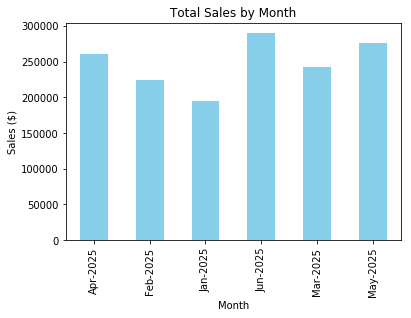


--- Diagnostic Analytics ---

Correlation Matrix:
                      Sales  Advertising_Spend    Profit
Sales              1.00000           0.982360  0.988060
Advertising_Spend  0.98236           1.000000  0.989395
Profit             0.98806           0.989395  1.000000


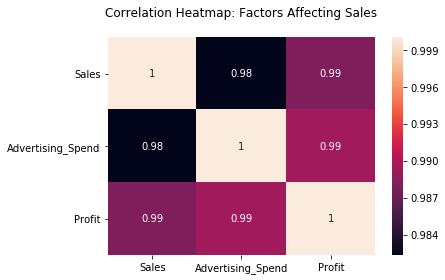


--- Predictive Analytics ---

Model Accuracy (R2 Score): 0.974357501026
Predicted Sales for $6,000 Spend: $37513.37

--- Prescriptive Analytics ---
Recommendation: Optimize Cost Strategy and evaluate marketing channel efficiency.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the Dataset
data = pd.read_csv("Sales_Dataset_2025.csv")


# 1. DESCRIPTIVE ANALYTICS (What happened?)

# This part summarizes the raw data to provide a 
# historical view of sales performance.
print("--- Descriptive Analytics ---\n")
print("Total Sales:", data['Sales'].sum())
print("Average Profit:", data['Profit'].mean())

# Visualizing the distribution of sales across months
monthly_sales = data.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='bar', color='skyblue')
plt.title("Total Sales by Month")
plt.ylabel("Sales ($)")
plt.show()


# 2. DIAGNOSTIC ANALYTICS (Why did it happen?)

print("\n--- Diagnostic Analytics ---\n")

# Select only numeric columns (FIX)
numeric_data = data.select_dtypes(include=['number'])

# Correlation calculation
correlation = numeric_data.corr()

print("Correlation Matrix:\n", correlation)

# Heatmap
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap: Factors Affecting Sales\n")
plt.show()


# 3. PREDICTIVE ANALYTICS (What will happen?)

# This part uses machine learning to forecast 
# future sales based on advertising investment.
print("\n--- Predictive Analytics ---\n")
X = data[['Advertising_Spend']]
y = data['Sales']

# Splitting and Training the Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluation
predictions = model.predict(X_test)
print("Model Accuracy (R2 Score):", r2_score(y_test, predictions))

# Forecasting for a future spend of $6,000
future_spend = [[6000]]
predicted_sales = model.predict(future_spend)
print(f"Predicted Sales for $6,000 Spend: ${predicted_sales[0]:.2f}")


# 4. PRESCRIPTIVE ANALYTICS (What should we do?)

# This part provides recommendations based on the 
# data findings to drive business decisions.
print("\n--- Prescriptive Analytics ---")
avg_sales = data['Sales'].mean()

if predicted_sales[0] > avg_sales:
    print("Recommendation: Increase Advertising Budget to maximize revenue growth.")
else:
    print("Recommendation: Optimize Cost Strategy and evaluate marketing channel efficiency.")